# Implementing Decision Tree Classifiers with Scikit-Learn

**Last Updated: 19 Jan, 2026**

A Decision Tree Classifier recursively splits data based on feature conditions to classify samples. Each internal node represents a feature condition, branches show outcomes, and leaf nodes assign class labels. This structure makes trees interpretable and effective for classification.

## DecisionTreeClassifier Syntax

```python
class sklearn.tree.DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None
)
```

---

## Key Parameters

### **criterion: Split Quality Metric**

Determines how splits are evaluated. Three options:

**Gini Index (default)**
- Measures impurity: Gini = 1 - Σ(p_i)²
- Simple example: Bag with 80 red and 20 blue balls. Gini tells how often a random guess fails
- **Pros:** Fast, works well for binary/balanced data
- **Cons:** Less optimal for multi-class problems

**Entropy**
- Measures information/uncertainty: Entropy = -Σ(p_i × log₂(p_i))
- Simple example: Higher entropy = more surprise/unpredictability
- **Pros:** Better for multi-class, theoretically sound
- **Cons:** Slower (logarithm calculations), may overfit

**Log Loss**
- Measures probability difference: Penalizes confident wrong predictions heavily
- Simple example: Predicting 90% spam for actual spam = low loss; predicting 10% = high loss
- **Pros:** Great for probability estimates and imbalanced data
- **Cons:** Slower, more sensitive to outliers

| Metric | Speed | Best For |
|--------|-------|----------|
| Gini | Fastest | Balanced data |
| Entropy | Medium | Multi-class |
| Log Loss | Slowest | Probability estimates |

---

### **splitter: Split Search Strategy**

**'best' (default)**
- Tests all possible splits for all features, picks the best one
- Simple example: Try every weight threshold to separate apples
- **Pros:** Highest quality tree, best generalizes
- **Cons:** Slow with large datasets, may overfit

**'random'**
- Randomly samples features, tests splits only on those
- Simple example: Randomly pick 2-3 features, find best split among them
- **Pros:** Much faster, reduces overfitting through randomness
- **Cons:** May miss optimal split, inconsistent quality

**When to use:** 'best' for small datasets (<100K rows), 'random' for large ones

---

### **max_features: Features to Consider per Split**

Controls how many features are evaluated when finding splits.

- **None (default):** All features considered
- **'sqrt':** √(total features) considered. Example: 16 features → considers 4
- **'log2':** log₂(total features) considered
- **Integer (e.g., 5):** Exactly 5 features considered
- **Float (e.g., 0.5):** 50% of features considered

**Effect:** Limiting features speeds up training and reduces overfitting, but may miss important splits.

**Guidance:** Start with 'sqrt', adjust based on performance.

---

### **class_weight: Handle Imbalanced Classes**

Assigns different penalties to misclassifying different classes.

**The Problem:** With 99% healthy and 1% disease cases, a naive model predicts "healthy" always and seems 99% accurate but useless.

**Options:**

- **None (default):** Equal weight for all classes
- **'balanced':** Auto-weights inversely to class frequency. Rare classes get higher weight.
  - Example: 990 healthy, 10 disease → disease weight ≈ 99, healthy weight ≈ 1
- **Dictionary {0: 1, 1: 5}:** Manually assign weights. Penalize class 1 misclassification 5x more.

**Example:** Fraud detection with 10,000 normal + 100 fraud cases:
- With 'balanced': Algorithm learns to catch fraud (high penalty for missing it)
- Without: Algorithm mostly predicts "normal" to minimize error

**Best practice:** Use 'balanced' for imbalanced data, fine-tune if needed.

---

### **ccp_alpha: Cost Complexity Pruning**

Controls pruning to remove unnecessary tree branches and prevent overfitting.

**The Problem:** Trees can memorize noise, growing too deep and performing poorly on new data.

**How it works:**

- **ccp_alpha = 0.0 (default):** No pruning, full tree growth
- **ccp_alpha = 0.001-0.01 (small):** Mild pruning, weak branches removed
- **ccp_alpha = 0.1-0.5 (moderate):** Significant pruning, simpler tree
- **ccp_alpha > 0.5 (large):** Aggressive pruning, very simple tree

**Example:** House price prediction tree:
- No pruning: 50 specific rules like "if street X AND year Y AND Z bedrooms, then price..."
- With pruning (0.1): 10 general rules like "if expensive neighborhood, then higher price"
- Pruned tree generalizes better to new houses

**Effect:** Simpler, more interpretable trees with better generalization, but may lose some accuracy.

**Finding optimal value:** Test values (0, 0.001, 0.01, 0.1, 0.5, 1.0) with cross-validation, pick the best.

---

## Quick Summary

| Parameter | Purpose | Common Choice |
|-----------|---------|----------------|
| **criterion** | Split quality metric | 'gini' for balanced, 'entropy' for multi-class |
| **splitter** | Search strategy | 'best' for small data, 'random' for large |
| **max_features** | Features per split | 'sqrt' or 'log2' |
| **class_weight** | Handle imbalance | 'balanced' if classes unbalanced |
| **ccp_alpha** | Reduce overfitting | 0.01-0.1 (tune with cross-validation) |

## <br>Implementation

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_iris()

X = data.data
Y = data.target

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=99)

model = DecisionTreeClassifier(random_state=1)   # random_state=1 is used to ensure reproducibility of results
model.fit(X_train, Y_train)

Y_predict = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_predict)

print("Accuracy:", accuracy)

Accuracy: 0.9555555555555556


## <br>Hyperparameter Tuning

#### **Grid Search**
Tests all combinations. **Pros:** Guaranteed best | **Cons:** Slow

#### **Random Search**
Randomly samples combinations. **Pros:** Fast | **Cons:** May miss best

#### **Bayesian Optimization**
Tests promising areas based on past results. **Pros:** Most efficient | **Cons:** Complex

| Method | Speed | Best For |
|--------|-------|----------|
| Grid | Slow | 1-2 params |
| Random | Fast | 3-5 params |
| Bayesian | Fastest | 5+ params |

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ['entropy', 'gini']
}

tree = DecisionTreeClassifier(random_state=1)

# GridSearchCV will perform an exhaustive search over the specified parameter grid, 
# using 5-fold cross-validation to evaluate the performance of each combination of parameters. 
# The best combination of parameters will be selected based on the highest accuracy score.
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, verbose=True)
grid_search.fit(X_train, Y_train)

print("best accuracy:  ", grid_search.best_score_)
print("best estimator: ", grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy:   0.9714285714285715
best estimator:  DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3,
                       random_state=1)


## <br> Visualizing the Decision Tree Classifier

Decision Tree visualization helps interpret and comprehend the model's decision-making process. We can visualize:

- **Tree Structure:** The actual splits and branches the model creates
- **Feature Importance:** Which features have the greatest predictive power for classification

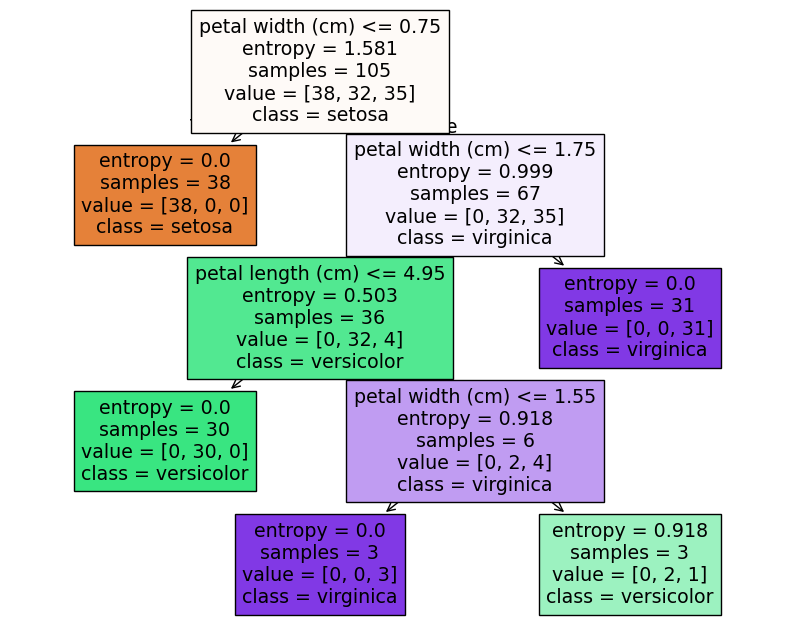

In [50]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = grid_search.best_estimator_

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()